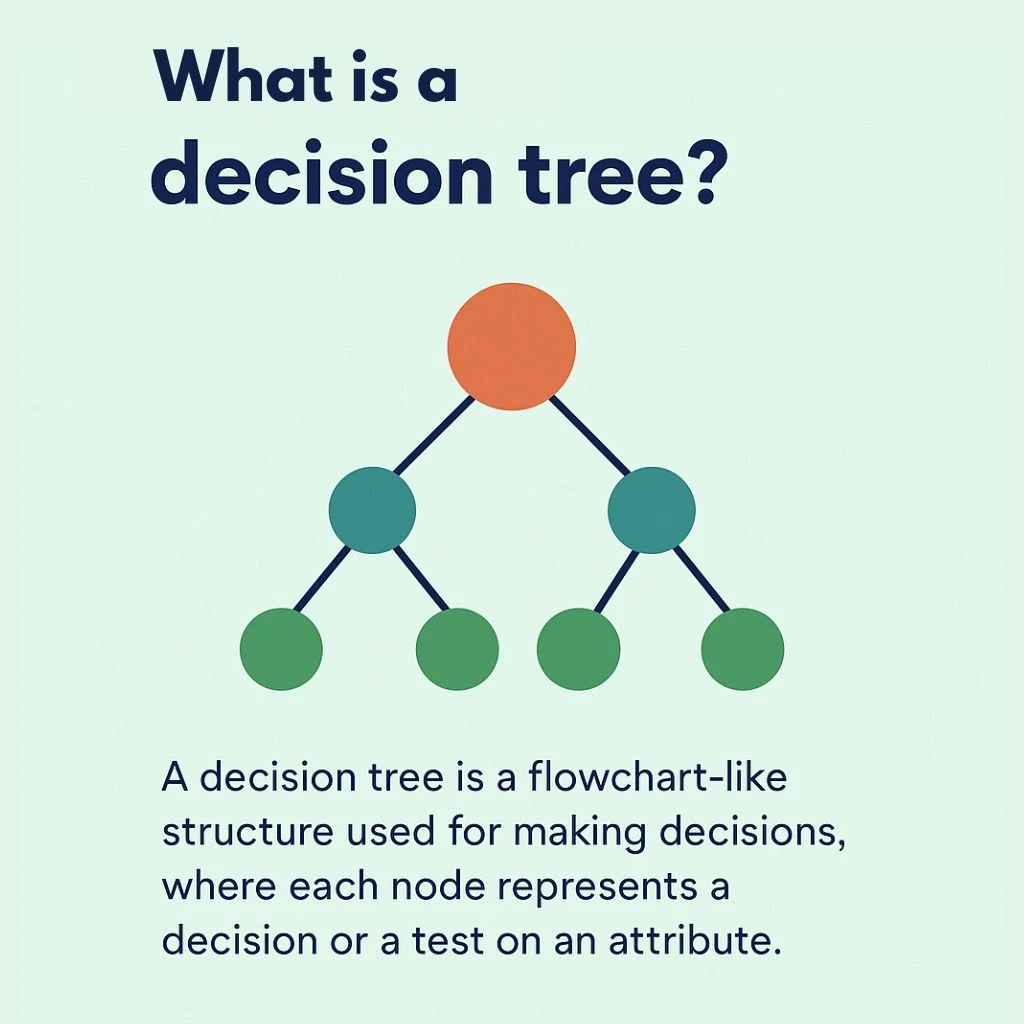

#**Decision Tree**

##**Introduction to Decision Trees**

* Decision Trees are supervised machine learning models used for:

    * Classification (predict categories)

    * Regression (predict numerical values)


* It is basically a model that predicts outcomes by asking a sequence of yes/no questions about the input features.

* It has a tree-like structure that starts with one main question called the root node which represents the entire dataset. From there, the tree branches out into different possibilities based on features in the data.



<br>

**Note:** *Not the same as "general decision trees"*

Be careful — when you Google “decision tree” you may see flowcharts (e.g., coin flip outcomes). Those are NOT machine-learning decision trees. Machine-learning decision trees learn the splits automatically by measuring information.




##**Basic Terminology**


                     [ Root Node ]
                      X ≤ 1.0 ?
                     /          \
                 Yes              No
             [Leaf: Y=1.5]     [Split X≤2?]
                                 /      \
                           [Y=2.2]    [Y=1.5]





* **Node:** A point where data is split based on a condition.

* **Root Node:** The first (top) split, or starting point representing the whole dataset.

* **Leaf / Terminal Node:** A node with no further splits → final prediction. End points of the tree where the final decision or prediction is made.

* **Internal Nodes:** Points where decisions are made based on data features.

* **Branches:** Lines connecting nodes showing the flow from one decision to another.

* **Splitting:** Applying a condition such as: X ≤ 2? → True branch / False branch.

* **Pruning:** Removing unnecessary splits to reduce overfitting.



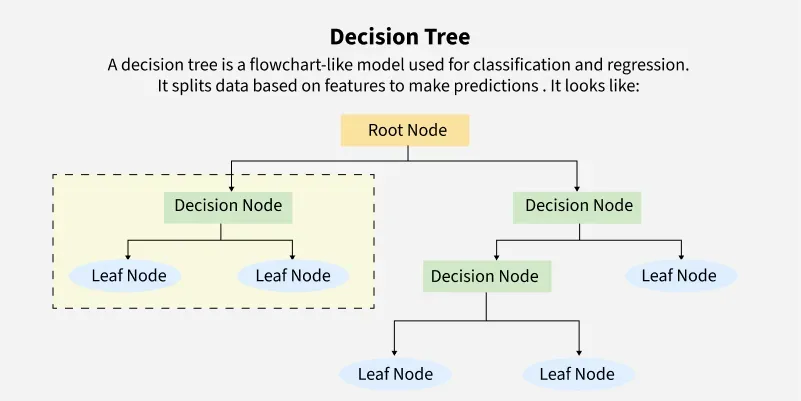


##**How Decision Trees Work?**

* A decision tree recursively splits the dataset based on feature values to create pure subsets/nodes ideally all items in a group belong to the same class.

* A node is ***pure*** when all samples belong to one class.

* Each leaf node of the tree corresponds to a class label and the internal nodes are feature-based decision points.

* **Splitting Rule:**  Choose the feature that reduces impurity **the most**, in other words maximize "purity" of the resulting child nodes.

* This reduction is called **Information Gain**.

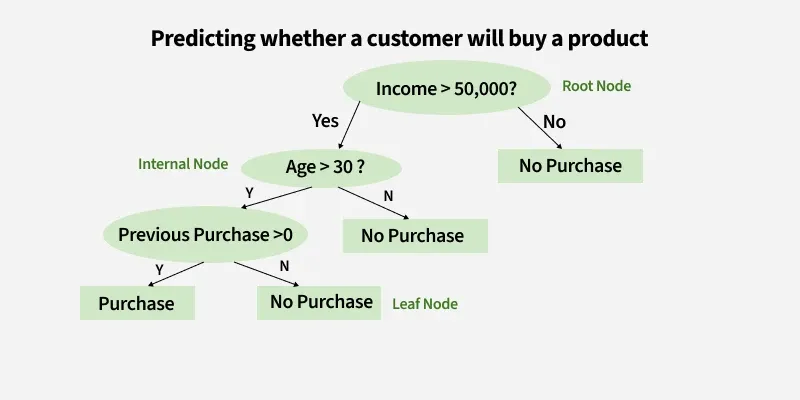

##**Why We Need an “Information Metric”?**

A decision tree must decide:

  * ***Which feature should we split first?***

  * ***Where should we split (threshold)?***

This requires a way to measure how pure or informative a node is.

<br>

**Why not go randomly?**

Consequences:

* Some nodes may become less pure than in the original tree.

* Overall tree may become deeper because splits are not as optimal.

* Accuracy may drop slightly (especially for small datasets).


<br>


So, We Need an **“Information Metric”**:

Common splitting criteria include:
* **Gini Impurity/Index:** This criterion measures how "impure" a node is. The lower the Gini Impurity the better the feature splits the data into distinct categories.

* **Entropy:** This measures the amount of uncertainty or disorder in the data. The tree tries to reduce the entropy by splitting the data on features that provide the most information about the target variable.

##**Gini Impurity**


Gini Impurity measures the probability of misclassifying a randomly chosen element:


$$G(Q) = 1 - \sum_{i=1}^{C} p_i^2$$


Where:

$~~~~~~~$ $p_i$ = fraction of class $i$ in node $Q$

**Intuition:**

  * Gini = 0 → node is pure
  * Gini maximum → node is most impure





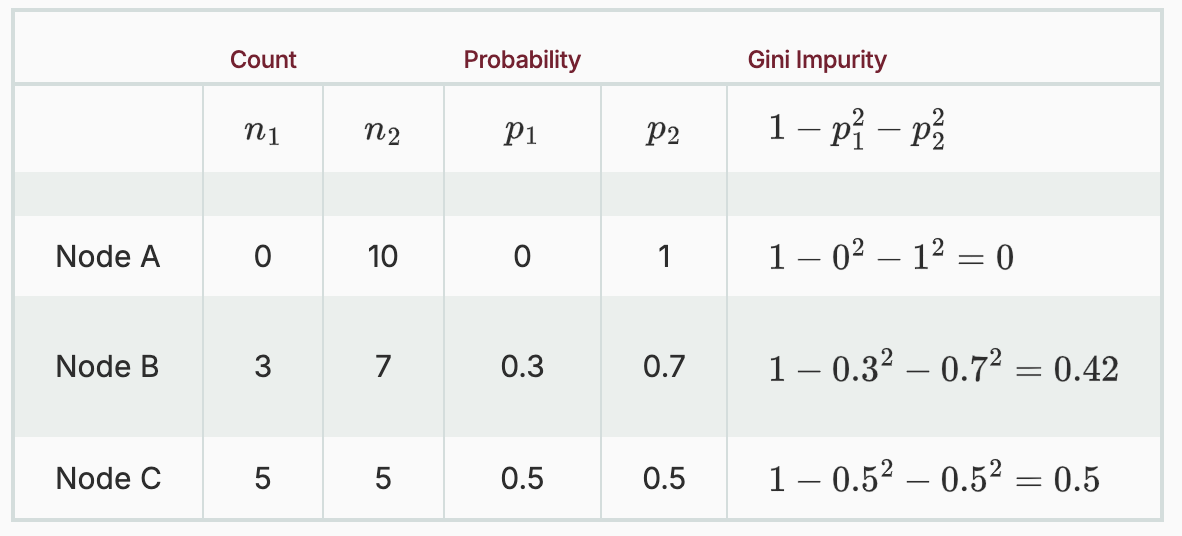


##**How Gini Guides the Split**

- Gini impurity is defined for a single node.
- But when you're choosing a split, you're not evaluating one node — you're evaluating:

  - **a transformation:** parent → multiple child nodes

- So the question is not: *“How impure is this node?”*
- but rather: *“If I split here, how good are the resulting nodes?”*


To evaluate a potential split, the algorithm computes:

1. **Gini impurity of the parent node:** Measures how mixed the classes are before the split.

2. **Gini impurity of each child node:** After the split, each child node has its own class distribution.

3. **Weighted Gini of the split:** More samples in a child node → higher weight.

**The formula for a split is:**

$$
G_{\text{split}} = \sum_{j=1}^{m} \frac{N_j}{N} G_j
$$


Where:

* $N_j$ = number of samples in child node

* $N$ = total samples in parent node

* $G_j$ = gini impurity of child node

* $m$ = number of children (usually 2 in binary splits)


##**Gini Reduction (Equivalent to Information Gain)**

* Decision Trees using Gini choose the split that reduces **impurity the most**.

* The tree checks how much impurity decreases after splitting.


* Gini Gain = impurity before split – impurity after split:

$$Gini Gain = 𝐺_{parent} − 𝐺_{split}$$



* The feature that creates the purest groups with  **highest Gini Gain** (or equivalently, **lowest weighted Gini**) becomes the next node.

* This process repeats recursively until nodes become pure or no further improvement is possible.


<br>

##**Constructing Decision Tree using Gini Impurity**


###**Step 0: Dataset Example Dataset**

We’ll classify whether a person buys a product (Yes/No) based on 4 features:


| ID | Age   | Income | Student | Credit_Rating | Buys_Product |
| -- | ----- | ------ | ------- | ------------- | ------------ |
| 1  | <=30  | High   | No      | Fair          | No           |
| 2  | <=30  | High   | No      | Excellent     | No           |
| 3  | 31-40 | High   | No      | Fair          | Yes          |
| 4  | >40   | Medium | No      | Fair          | Yes          |
| 5  | >40   | Low    | Yes     | Fair          | Yes          |
| 6  | >40   | Low    | Yes     | Excellent     | No           |
| 7  | 31-40 | Low    | Yes     | Excellent     | Yes          |
| 8  | <=30  | Medium | No      | Fair          | No           |
| 9  | <=30  | Low    | Yes     | Fair          | Yes          |
| 10 | >40   | Medium | Yes     | Fair          | Yes          |

<br>

**Feature explanation:**

* Age: <=30, 31-40, >40

* Income: Low, Medium, High

* Student: Yes, No

* Credit_Rating: Fair, Excellent

* Target: Buys_Product (Yes/No)

### **Step 1: Compute Gini impurity for root node**

Root node has 10 samples:  
- Yes = 6, No = 4  

$$
G_{\text{root}} = 1 - (p_\text{Yes}^2 + p_\text{No}^2)
$$

$$
G_{\text{root}} = 1 - \left(\left(\frac{6}{10}\right)^2 + \left(\frac{4}{10}\right)^2\right) = 0.48
$$



### **Step 2: Consider splits for each feature**
We calculate weighted Gini for each possible split. Let’s go feature by feature.

---

**Feature: Age**
- Split: Age <=30 vs Age >30  
<br>

| Node  | IDs             | Yes | No | Gini  |
|-------|-----------------|-----|----|-------|
| Left  | 1,2,8,9         | 1   | 3  | 0.375 |
| Right | 3,4,5,6,7,10    | 5   | 1  | 0.278 |

$$
G_\text{Left} = 1 - ((\frac{1}{4})^2 + (\frac{3}{4})^2) = 1- (0.0625+0.5625) = 0.375
$$

$$
G_\text{Right} = 1 - ((\frac{5}{6})^2 + (\frac{1}{6})^2) = 1- (0.694+0.028) = 0.278
$$


Weighted Gini:  

$$
G_\text{split} = \frac{4}{10} \cdot 0.375 + \frac{6}{10} \cdot 0.278 = 0.317
$$

---

**Feature: Income**
- Split: High vs Medium vs Low  
<br>

| Node   | IDs             | Yes | No | Gini  |
|--------|-----------------|-----|----|-------|
| High   | 1,2,3           | 1   | 2  | 0.444 |
| Medium | 4,8,10          | 2   | 1  | 0.444 |
| Low    | 5,6,7,9         | 3   | 1  | 0.375 |

$$
G_\text{High} = 1 - \left((\frac{1}{3})^2 + (\frac{2}{3})^2\right) = 0.444
$$

$$
G_\text{Medium} = 1 - \left((\frac{2}{3})^2 + (\frac{1}{3})^2\right) = 0.444
$$

$$
G_\text{Low} = 1 - \left((\frac{3}{4})^2 + (\frac{1}{4})^2\right) = 0.375
$$

Weighted Gini:  

$$
G_\text{split} = \frac{3}{10}\cdot 0.444 + \frac{3}{10}\cdot 0.444 + \frac{4}{10}\cdot 0.375 = 0.416
$$


---

**Feature: Student**
- Split: Yes vs No  
<br>

| Node  | IDs              | Yes | No | Gini  |
|-------|-----------------|-----|----|-------|
| Yes   | 5,6,7,9,10       | 4   | 1  | 0.32  |
| No    | 1,2,3,4,8        | 2   | 3  | 0.48  |

$$
G_\text{Yes} = 1 - \left((\frac{4}{5})^2 + (\frac{1}{5})^2\right) = 0.32
$$

$$
G_\text{No} = 1 - \left((\frac{2}{5})^2 + (\frac{3}{5})^2\right) = 0.48
$$

Weighted Gini:  

$$
G_\text{split} = \frac{5}{10}\cdot0.32 + \frac{5}{10}\cdot0.48 = 0.40
$$


---

**Feature: Credit_Rating**
- Split: Fair vs Excellent  
<br>

| Node      | IDs             | Yes | No | Gini  |
|-----------|----------------|-----|----|-------|
| Fair      | 1,3,4,5,8,9,10 | 5   | 2  | 0.408 |
| Excellent | 2,6,7          | 1   | 2  | 0.444 |

$$
G_\text{Fair} = 1 - \left((\frac{5}{7})^2 + (\frac{2}{7})^2\right) = 0.408
$$

$$
G_\text{Excellent} = 1 - \left((\frac{1}{3})^2 + (\frac{2}{3})^2\right) = 0.444
$$

Weighted Gini:  

$$
G_\text{split} = \frac{7}{10}\cdot0.408 + \frac{3}{10}\cdot0.444 = 0.418
$$

---


<br>

### **Step 3: Choose Best Split**


- Gini for splits:  
  - Age: 0.317 ✅ **smallest**  
  - Income: 0.416  
  - Student: 0.40  
  - Credit_Rating: 0.418  

**Best split: Age**

### **Step 4: Split Node**

- Left child: Age <=30 → IDs [1,2,8,9] → Yes=1, No=3  
- Right child: Age >30 → IDs [3,4,5,6,7,10] → Yes=5, No=1  

### **Step 5: Check Stopping Criteria**

- Left child: Gini=0.375 → not pure → continue splitting  
- Right child: Gini=0.278 → not pure → continue splitting  


### **Step 6: Recursively Split Children**

**Left Child: Age <=30 (IDs [1,2,8,9])**  

- Feature: Student  
  - Yes → [9] → Gini=0  
  - No → [1,2,8] → Gini=0

Weighted Gini = 0 → perfect split  

**Split by Student. Node becomes pure leaves.**

<br>

**Right Child: Age >30 (IDs [3,4,5,6,7,10])**

- Feature: Student  
  - Yes → [5,6,7,10] → Yes=3, No=1 → Gini=0.375  
  - No → [3,4] → Yes=2, No=0 → Gini=0  

Weighted Gini = 0.25 → best split  

**Split by Student. Continue splitting until all nodes are pure.**


### **Step 7: Assign Class to Leaves**

- Each leaf node → majority class of samples in that node.  
- Tree is now fully grown for this dataset.

### **Step 8: Tree Prediction Logic**

- Start at root → follow feature splits based on sample values → stop at leaf → predicted class = majority class of leaf.


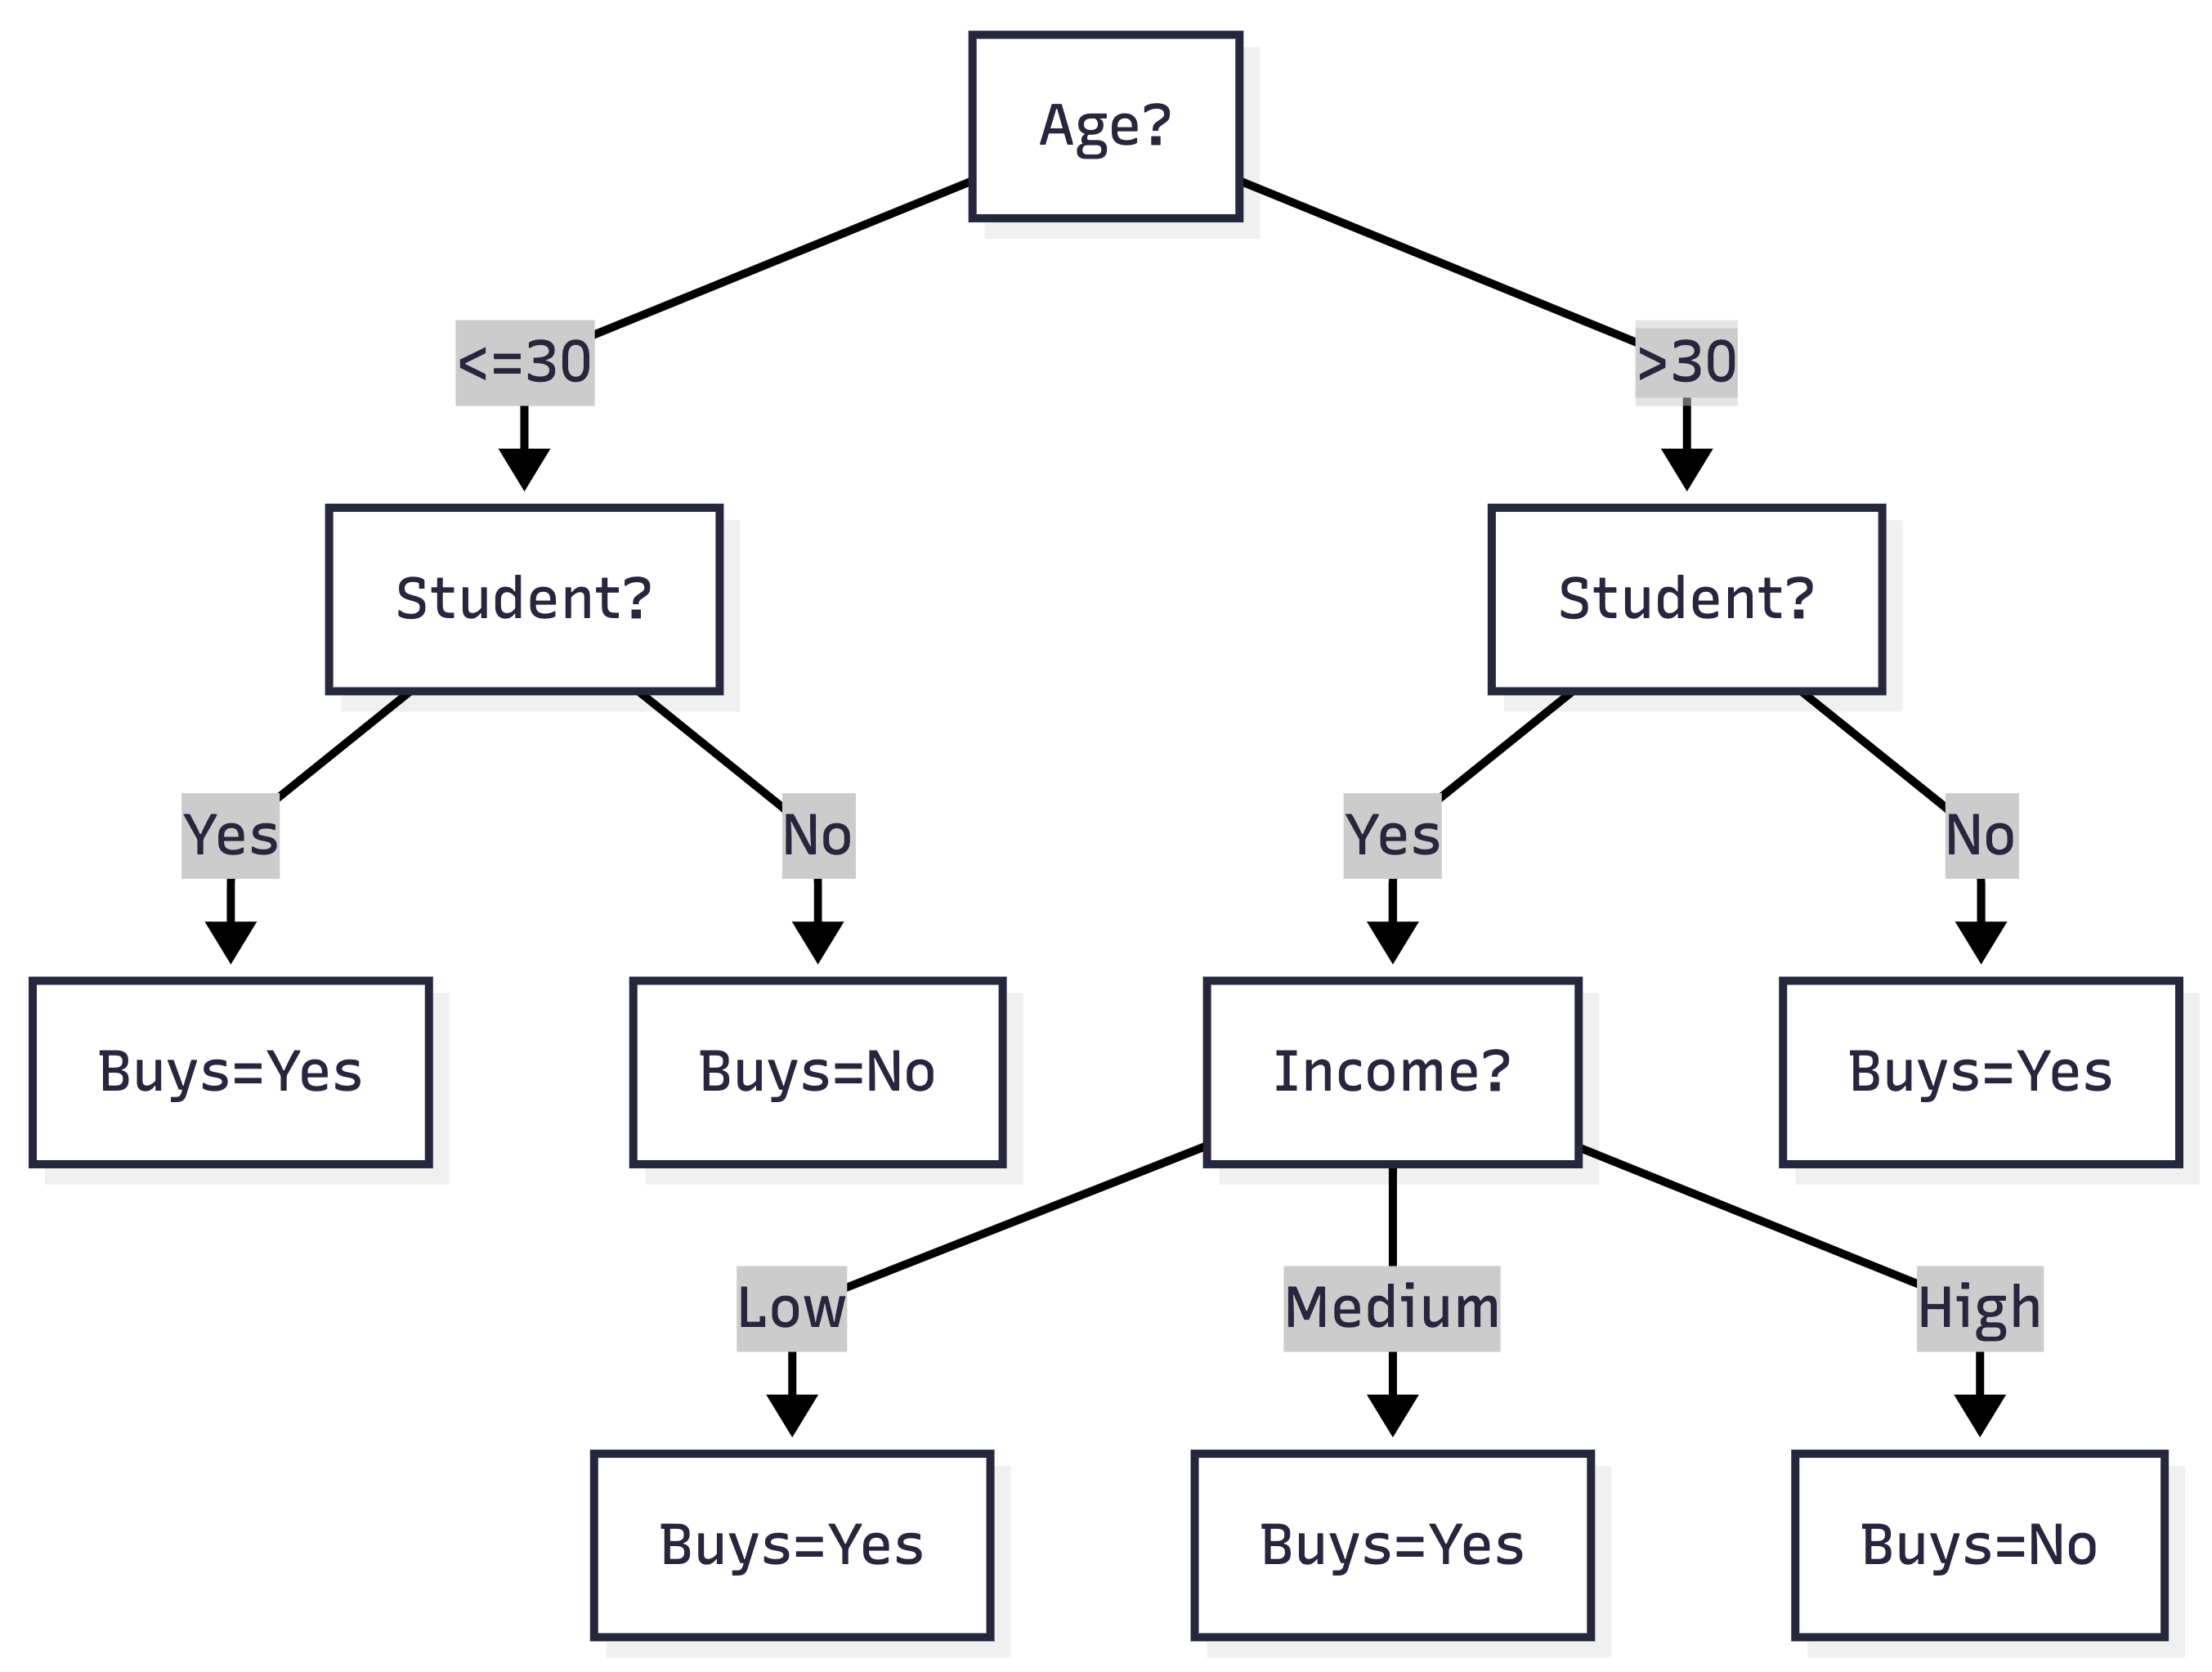

##**Train a Decision Tree Classifier Using Gini Impurity**

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



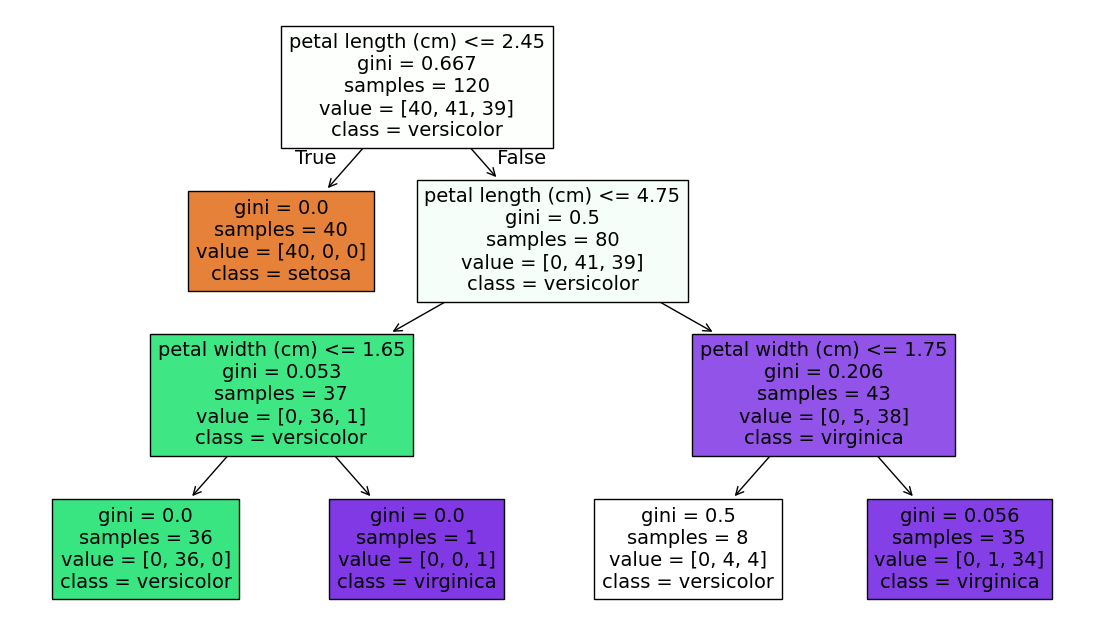

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Load a dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train decision tree
tree = DecisionTreeClassifier(criterion="gini",max_depth=3,random_state=42)
tree.fit(X_train, y_train)

# Predictions
y_pred = tree.predict(X_test)
print("Accuracy:", tree.score(X_test, y_test))
print(classification_report(y_test, y_pred))

# Visualize tree
plt.figure(figsize=(14,8))
plot_tree(tree, feature_names=iris.feature_names,
          class_names=iris.target_names, filled=True)
plt.show()


##**Pruning (Avoiding Overfitting)**

A decision tree keeps splitting until:

- nodes are pure (Gini = 0), or
- it runs out of stopping conditions

This often leads to:

- very deep trees
- tiny leaves (even 1 sample!)
- perfect training accuracy
- poor generalization


<br>

#### **Pruning = controlling or reducing tree complexity**

Two main strategies:

| Type             | When applied             |
| ---------------- | ------------------------ |
| **Pre-pruning**  | During tree growth       |
| **Post-pruning** | After full tree is built |


<br>


### **Pre-pruning:** Limit tree growth (Early Stopping)

Instead of growing the full tree, we stop splitting early based on rules.

- **max_depth:** Limits how deep the tree can grow

  - Depth = number of decisions from root to leaf
  - Small depth → simpler model

- **min_samples_split:** A node must have at least specific number of samples to be split

  - Prevents splitting small datasets

- **min_samples_leaf:** Each leaf must have at least specific number of samples

  - Forces leaves to represent groups, not individual points





Accuracy: 0.9666666666666667


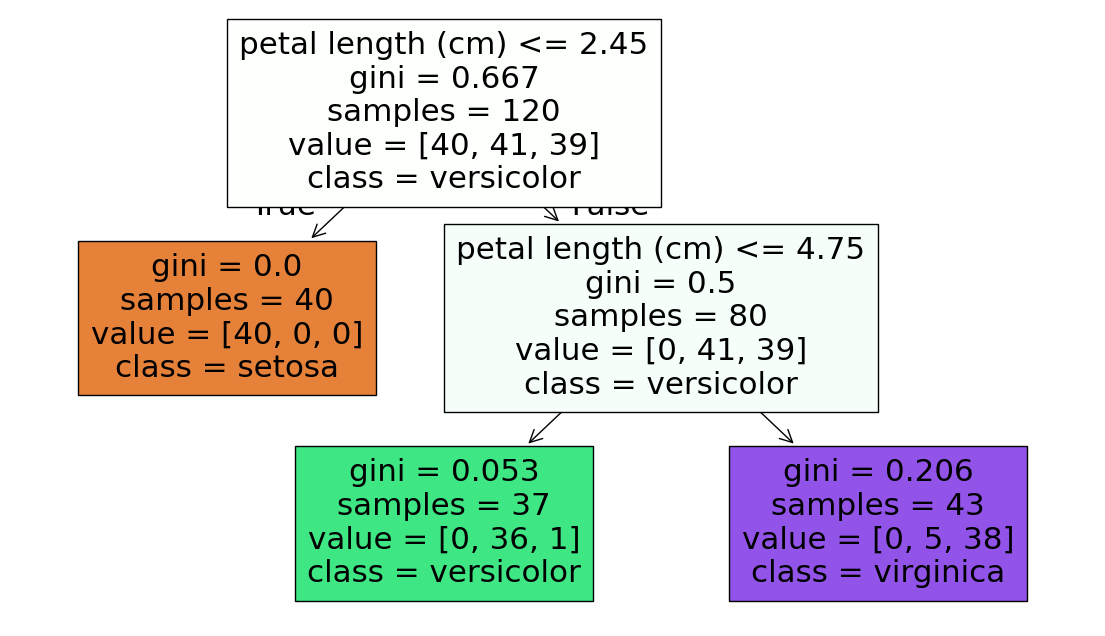

In [ ]:
ptree = DecisionTreeClassifier(max_depth=2, criterion='gini')
ptree.fit(X_train, y_train)
print("Accuracy:", ptree.score(X_test, y_test))


# Visualize tree
plt.figure(figsize=(14,8))
plot_tree(ptree, feature_names=iris.feature_names,
          class_names=iris.target_names, filled=True)
plt.show()


### **Post-pruning (Cost Complexity Pruning)**

Instead of stopping early:

 - Grow a large (possibly overfit) tree first, then prune it back.

So the workflow is:

 - Grow full tree (or very deep tree)
 - Remove branches that don’t improve generalization

In [ ]:
from sklearn.tree import DecisionTreeClassifier
path = tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)


[0.         0.01621622 0.0241196  0.24326537 0.33340278]


##**Entropy**

Entropy is a measure of **impurity**, **uncertainty**, or **disorder** in a dataset.
Decision Trees use entropy to decide which feature to split on — the goal is to create groups that are **as pure as possible**.


Entropy answers the question: *"How mixed are the classes in this dataset?"*

* High entropy → classes are mixed → more disorder
* Low entropy → classes are pure → less disorder

A node with **entropy = 0** is perfectly pure (all samples from one class).

<br>

**Entropy Formula:**

For a dataset $D$ with classes $c_1, c_2, \dots, c_k$:

$$
H(D) = - \sum_{i=1}^{k} p_i \log_2(p_i)
$$

Where:

- $p_i$ = probability of class $i$  
- $k$ = number of classes  





<br>

**Key Rules of Entropy:**

If all samples belong to one class:

$$
H = 0
$$

Maximum entropy happens when classes are **perfectly balanced**.  
Example for 2 classes, each with probability \(0.5\):

$$
H = - (0.5 \log_2(0.5) + 0.5 \log_2(0.5)) = 1
$$

Entropy ranges:

$$
0 \le H \le \log_2(k)
$$

For **binary** classification:

$$
0 \le H \le 1
$$



<br>

**Example:** Entropy With Two Classes

If a node contains:

- 9 samples of class **Yes**  
- 5 samples of class **No**

Probabilities:

$$
p_{yes} = \frac{9}{14}, \quad p_{no} = \frac{5}{14}
$$

Entropy:

$$H = -[ (9/14) log2(9/14) + (5/14) log2(5/14) ]$$

<br>


##**How Entropy Guides the Split (Equivalent to Gini Gain)**

Entropy helps the tree decide which split creates more order.

We compute:

1. Entropy of the parent node
2. Entropy of each child node
3. Weighted average entropy after the split
4. Information Gain:

$$IG=H(parent)−H(children)$$

The feature with the **highest information gain** becomes the next split.

<br>

##**Constructing Decision Tree using Entropy**


###**Step 1: Entropy for Root Node**

Root node has 10 samples: Yes = 6, No = 4.

$$
H_{\text{root}} = -\sum_{i} p_i \log_2 p_i
= -\left(\frac{6}{10}\log_2\frac{6}{10} + \frac{4}{10}\log_2\frac{4}{10}\right)
$$

Numerically:

$$
H_{\text{root}} \approx -\left(0.6\log_2 0.6 + 0.4\log_2 0.4\right) \approx 0.9709505945
$$

---


###**Step 2: Compute Weighted Entropy and Information Gain for Each Feature**


**Feature: Age**
- Split: Age ≤ 30 vs Age > 30  
<br>

| Node  | IDs             | Yes | No | Entropy |
|-------|-----------------|-----|----|---------|
| Left  | 1,2,8,9         | 1   | 3  | 0.8112781245 |
| Right | 3,4,5,6,7,10    | 5   | 1  | 0.6500224216 |

Left entropy:

$$
H_{\text{Left}} = -\left(\frac{1}{4}\log_2\frac{1}{4} + \frac{3}{4}\log_2\frac{3}{4}\right)
\approx 0.8112781245
$$

Right entropy:

$$
H_{\text{Right}} = -\left(\frac{5}{6}\log_2\frac{5}{6} + \frac{1}{6}\log_2\frac{1}{6}\right)
\approx 0.6500224216
$$

Weighted entropy:

$$
H_{\text{split}} = \frac{4}{10}\cdot 0.8112781245 + \frac{6}{10}\cdot 0.6500224216 \approx 0.7145247028
$$

Information Gain:

$$
IG(\text{Age}) = H_{\text{root}} - H_{\text{split}} \approx 0.9709505945 - 0.7145247028 \approx 0.2564258917
$$

---

**Feature: Income**
- Split: High vs Medium vs Low  
<br>

| Node   | IDs             | Yes | No | Entropy |
|--------|-----------------|-----|----|---------|
| High   | 1,2,3           | 1   | 2  | 0.9182958341 |
| Medium | 4,8,10          | 2   | 1  | 0.9182958341 |
| Low    | 5,6,7,9         | 3   | 1  | 0.8112781245 |

Entropies:

$$
H_{\text{High}} = -\left(\frac{1}{3}\log_2\frac{1}{3} + \frac{2}{3}\log_2\frac{2}{3}\right) \approx 0.9182958341
$$

$$
H_{\text{Medium}} = H_{\text{High}} \approx 0.9182958341
$$

$$
H_{\text{Low}} = -\left(\frac{3}{4}\log_2\frac{3}{4} + \frac{1}{4}\log_2\frac{1}{4}\right) \approx 0.8112781245
$$

Weighted entropy:

$$
H_{\text{split}} = \frac{3}{10}\cdot0.9182958341 + \frac{3}{10}\cdot0.9182958341 + \frac{4}{10}\cdot0.8112781245 \approx 0.8754887502
$$

Information Gain:

$$
IG(\text{Income}) = H_{\text{root}} - H_{\text{split}} \approx 0.9709505945 - 0.8754887502 \approx 0.0954618442
$$

---

**Feature: Student**
- Split: Yes vs No  
<br>

| Node  | IDs              | Yes | No | Entropy |
|-------|------------------|-----|----|---------|
| Yes   | 5,6,7,9,10       | 4   | 1  | 0.7219280949 |
| No    | 1,2,3,4,8        | 2   | 3  | 0.9709505945 |

Entropies:

$$
H_{\text{Yes}} = -\left(\frac{4}{5}\log_2\frac{4}{5} + \frac{1}{5}\log_2\frac{1}{5}\right) \approx 0.7219280949
$$

$$
H_{\text{No}} = -\left(\frac{2}{5}\log_2\frac{2}{5} + \frac{3}{5}\log_2\frac{3}{5}\right) \approx 0.9709505945
$$

Weighted entropy:

$$
H_{\text{split}} = \frac{5}{10}\cdot0.7219280949 + \frac{5}{10}\cdot0.9709505945 \approx 0.8464393447
$$

Information Gain:

$$
IG(\text{Student}) = H_{\text{root}} - H_{\text{split}} \approx 0.9709505945 - 0.8464393447 \approx 0.1245112498
$$

---

**Feature: Credit_Rating**
- Split: Fair vs Excellent  
<br>

| Node      | IDs             | Yes | No | Entropy |
|-----------|------------------|-----|----|---------|
| Fair      | 1,3,4,5,8,9,10   | 5   | 2  | 0.8631205686 |
| Excellent | 2,6,7            | 1   | 2  | 0.9182958341 |

Entropies:

$$
H_{\text{Fair}} = -\left(\frac{5}{7}\log_2\frac{5}{7} + \frac{2}{7}\log_2\frac{2}{7}\right) \approx 0.8631205686
$$

$$
H_{\text{Excellent}} = -\left(\frac{1}{3}\log_2\frac{1}{3} + \frac{2}{3}\log_2\frac{2}{3}\right) \approx 0.9182958341
$$

Weighted entropy:

$$
H_{\text{split}} = \frac{7}{10}\cdot0.8631205686 + \frac{3}{10}\cdot0.9182958341 \approx 0.8796731482
$$

Information Gain:

$$
IG(\text{Credit\_Rating}) = H_{\text{root}} - H_{\text{split}} \approx 0.9709505945 - 0.8796731482 \approx 0.0912774462
$$

---


###**Step 3: Choose Best Split**

Information gains:

- $IG(\text{Age}) \approx 0.2564$ **(largest)**  
- $IG(\text{Student}) \approx 0.1245$  
- $IG(\text{Income}) \approx 0.0955 $  
- $IG(\text{Credit\_Rating}) \approx 0.0913$

**Best feature to split at root: `Age`.**

###**Step 4: Split Node (Age)**

- Left child: **Age ≤ 30** → IDs = [1,2,8,9] → Yes=1, No=3  
  - Entropy $H_{\text{Left}} \approx 0.8112781245$
- Right child: **Age > 30** → IDs = [3,4,5,6,7,10] → Yes=5, No=1  
  - Entropy $H_{\text{Right}} \approx 0.6500224216$

Both children are **not pure**, so continue recursively.


###**Step 5: Recursively split children (compute local best splits)**

**Left child (Age ≤ 30): IDs [1,2,8,9], Entropy ≈ 0.8112781245**

Consider split by **Student**:

| Branch | IDs   | Yes | No | Entropy |
|--------|-------|-----|----|---------|
| Yes    | [9]   | 1   | 0  | 0       |
| No     | [1,2,8] | 0 | 3  | 0       |

Weighted entropy:

$$
H_{\text{Student split}} = \frac{1}{4}\cdot 0 + \frac{3}{4}\cdot 0 = 0
$$

Information Gain on this node:

$$
IG = H_{\text{Left}} - 0 = 0.8112781245
$$

**This is a perfect split** (both branches pure). So for **Age ≤ 30** we split on **Student** and get leaves:

- Age ≤ 30 & Student = Yes → Buys = **Yes**
- Age ≤ 30 & Student = No  → Buys = **No**

<br>

---

<br>

**Right child (Age > 30): IDs [3,4,5,6,7,10], Entropy ≈ 0.6500224216**

Consider split by **Student**:

| Branch | IDs            | Yes | No | Entropy |
|--------|----------------|-----|----|---------|
| Yes    | [5,6,7,10]     | 3   | 1  | 0.8112781245 |
| No     | [3,4]          | 2   | 0  | 0            |

Weighted entropy:

$$
H_{\text{Student split}} = \frac{4}{6}\cdot0.8112781245 + \frac{2}{6}\cdot0 \approx 0.5408520820
$$

Information Gain (local):

$$
IG = H_{\text{Right}} - 0.5408520820 \approx 0.1091703387
$$

So `Student` is a good split for this node. After splitting:

- Age > 30 & Student = No  → IDs [3,4] → both **Yes** → leaf (Buys=Yes)
- Age > 30 & Student = Yes → IDs [5,6,7,10] → not pure → continue splitting


###**Step 6: Split Right→Student=Yes node (IDs [5,6,7,10], Entropy ≈ 0.8112781245)**

Consider split by **Income** (categories within this node: Low → [5,6,7], Medium → [10], High → none):

| Branch | IDs       | Yes | No | Entropy |
|--------|-----------|-----|----|---------|
| Low    | [5,6,7]   | 2   | 1  | 0.9182958341 |
| Medium | [10]      | 1   | 0  | 0            |
| High   | []        | 0   | 0  | (ignore empty) |

Weighted entropy (ignoring empty group):

$$
H_{\text{Income split}} = \frac{3}{4}\cdot0.9182958341 + \frac{1}{4}\cdot0 \approx 0.6887218755
$$

Information Gain (local):

$$
IG = 0.8112781245 - 0.6887218755 \approx 0.1225562499
$$

This split reduces entropy; after splitting:

- Age > 30 & Student = Yes & Income = Low  → IDs [5,6,7] → majority = **Yes** (2 Yes, 1 No) → leaf (predict Buys = Yes)
- Age > 30 & Student = Yes & Income = Medium → ID [10] → pure → leaf (Buys = Yes)

(There are no High cases in this branch.)


###**Step 7: Assign class to leaves**

Summarizing the leaves:

- Age ≤ 30 & Student = Yes  → **Buys = Yes**
- Age ≤ 30 & Student = No   → **Buys = No**
- Age > 30  & Student = No   → **Buys = Yes**
- Age > 30  & Student = Yes & Income = Low    → **Buys = Yes** (majority)
- Age > 30  & Student = Yes & Income = Medium → **Buys = Yes**

All nodes are now leaves (pure or majority assigned).

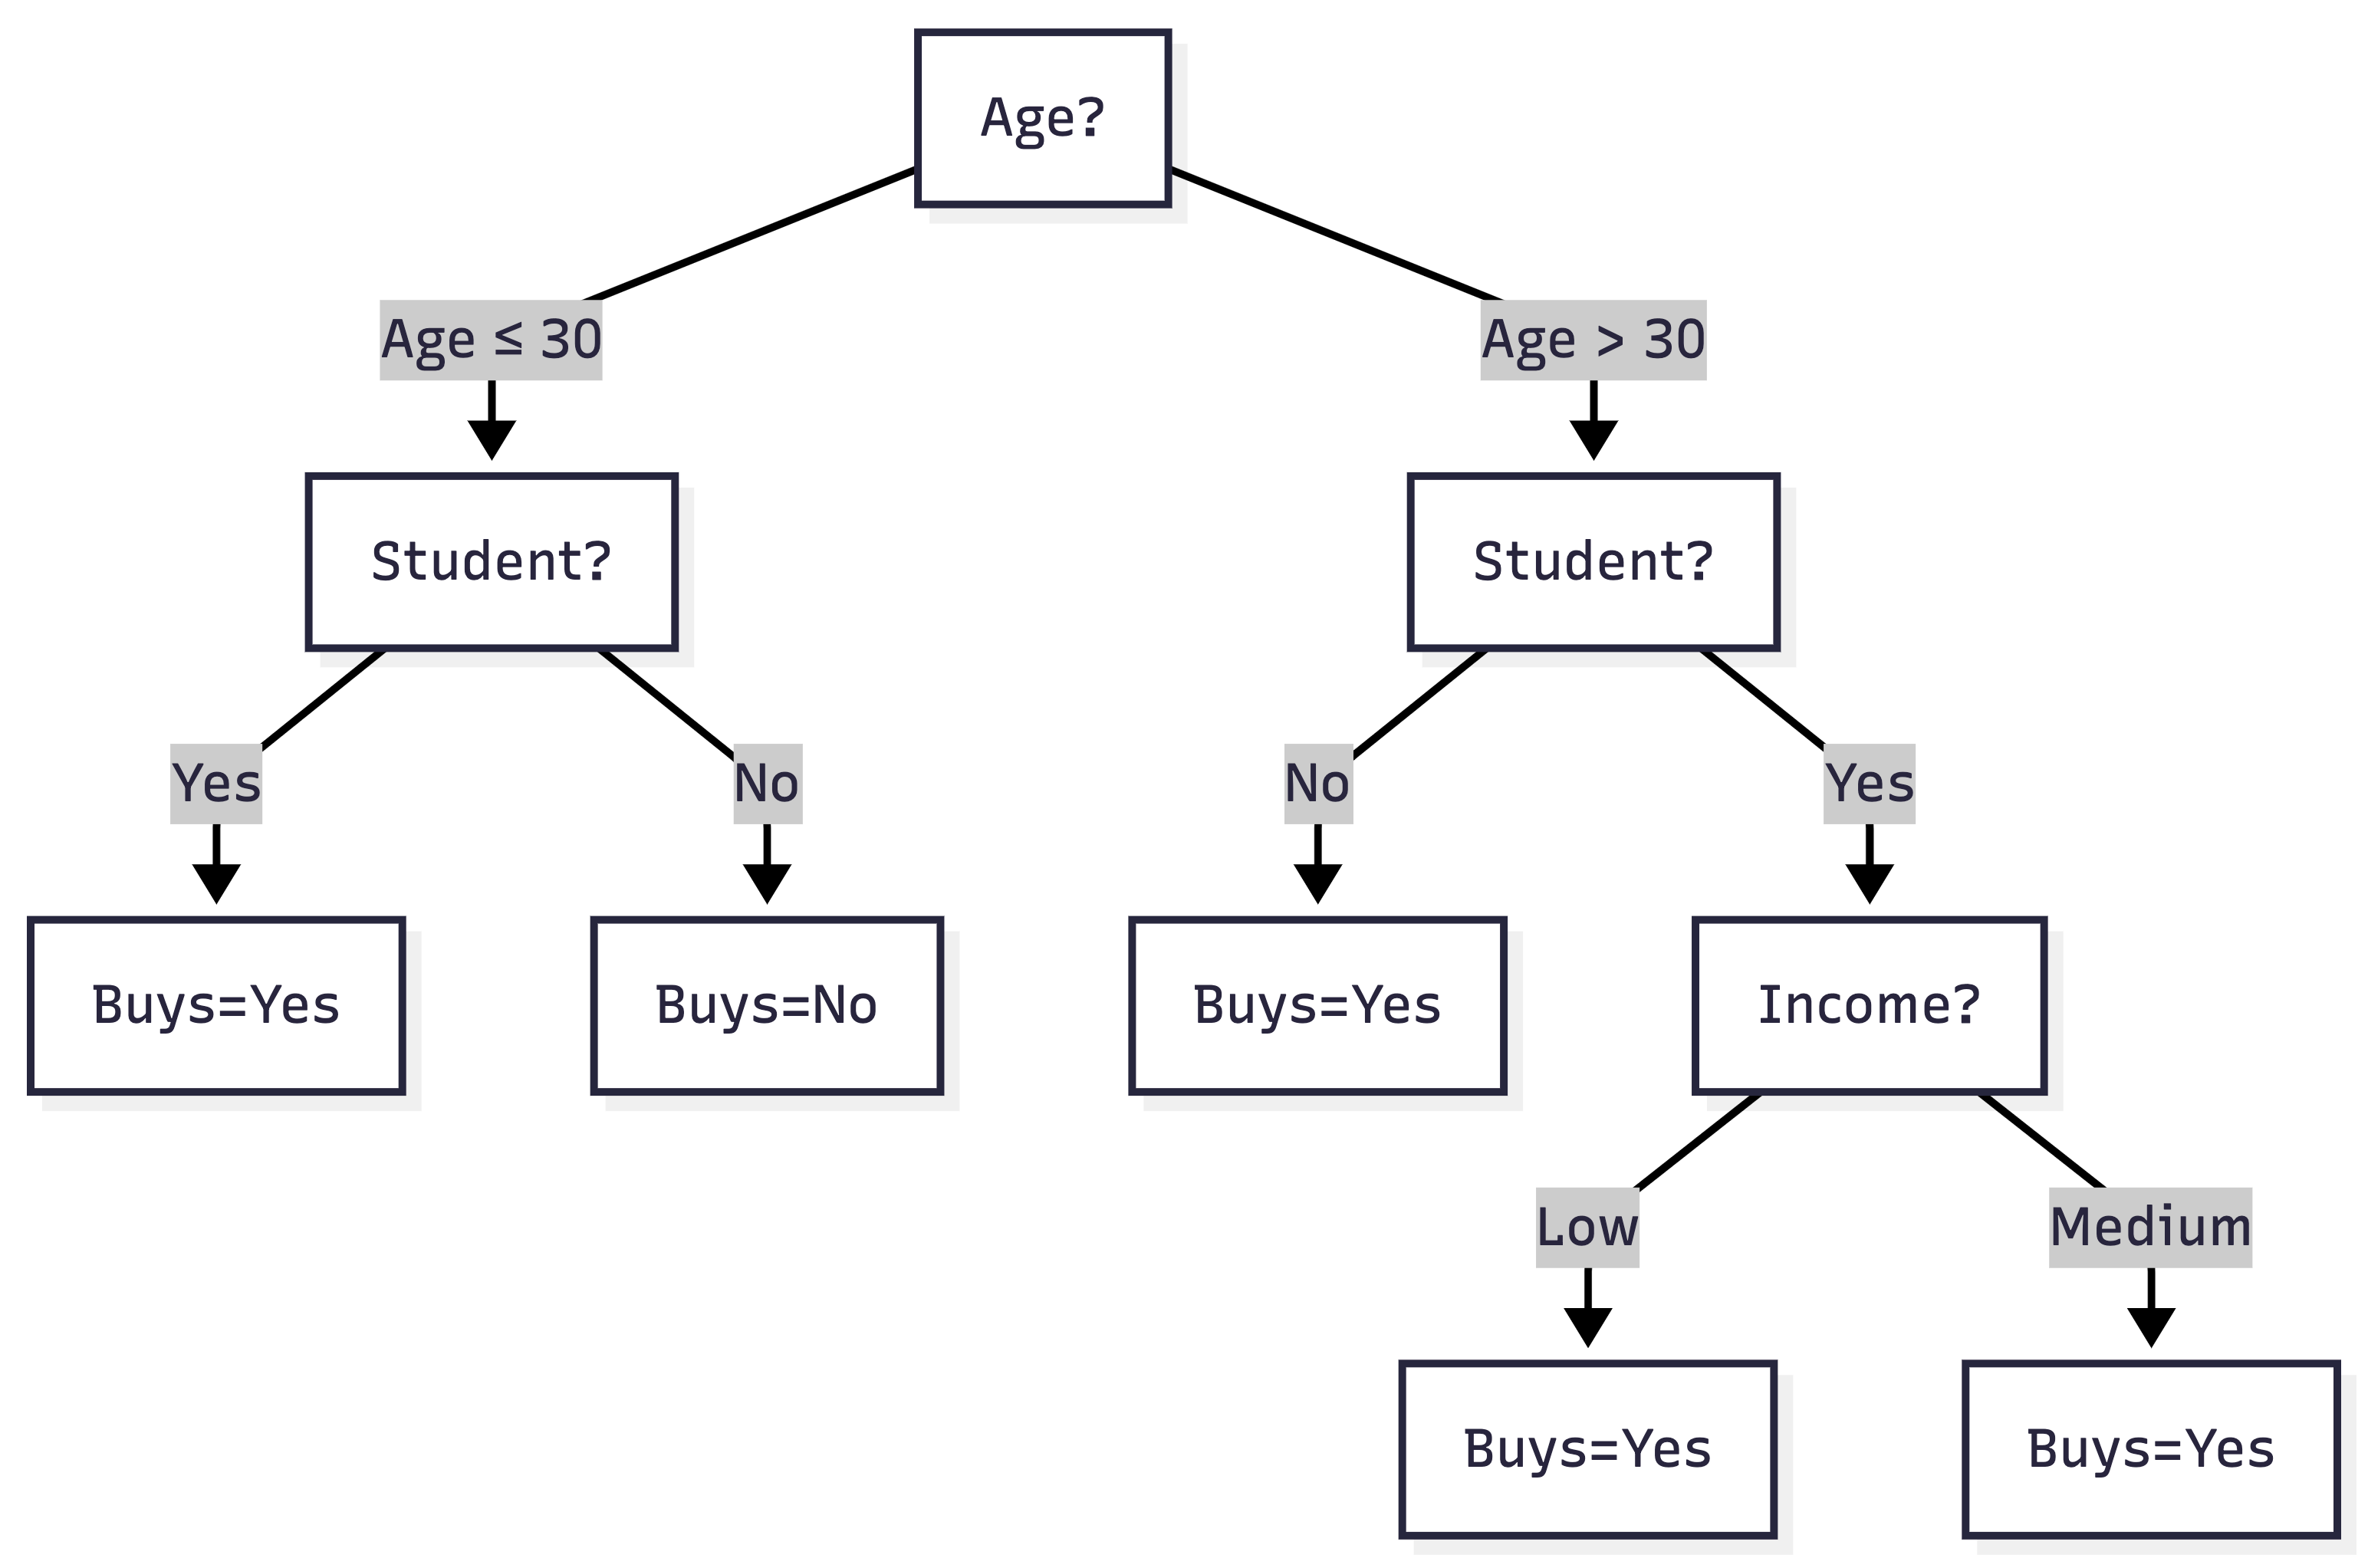

**Useful Resources:**

[Entropy @statquest](https://youtu.be/YtebGVx-Fxw?si=LtO65MfwA_uVKv4O)

##**Train a Decision Tree Classifier Using Entropy**

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



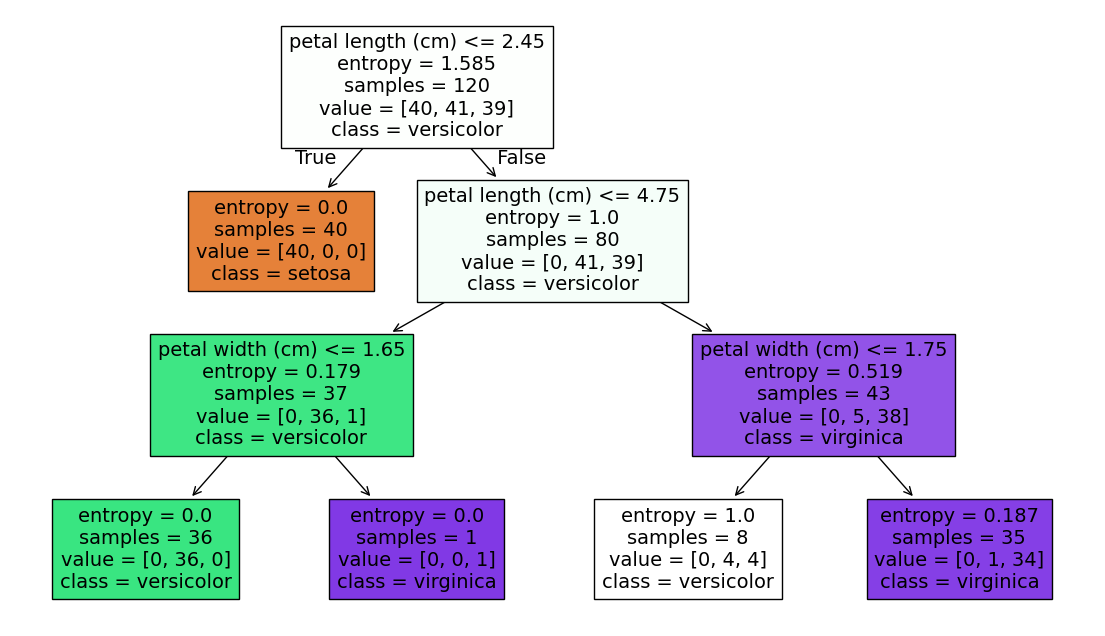

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Load a dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train decision tree
tree = DecisionTreeClassifier(criterion="entropy",max_depth=3,random_state=42)
tree.fit(X_train, y_train)

# Predictions
y_pred = tree.predict(X_test)
print("Accuracy:", tree.score(X_test, y_test))
print(classification_report(y_test, y_pred))

# Visualize tree
plt.figure(figsize=(14,8))
plot_tree(tree, feature_names=iris.feature_names,
          class_names=iris.target_names, filled=True)
plt.show()


##**Notes / Key Insights**

* Using Entropy / Information Gain we made exactly the same structural choices (Age first, then Student) as with Gini for this dataset — the numeric criteria differed but the greedy choice matched.

* At each node we compute the node entropy, then for every candidate split compute the weighted entropy of children and choose the split that maximizes information gain (equivalently minimizes weighted entropy).

* For small datasets like this, both Gini and Entropy often pick the same splits; differences typically appear for larger or more nuanced splits.


##**Advantages of Decision Trees**

* **Easy to Understand:** Decision Trees are visual which makes it easy to follow the decision-making process.

* **Versatility:** Can be used for both classification and regression problems.

* **No Need for Feature Scaling:** Unlike many machine learning models, it don’t require us to scale or normalize our data.

* **Handles Non-linear Relationships:** It capture complex, non-linear relationships between features and outcomes effectively.

* **Interpretability:** The tree structure is easy to interpret helps in allowing users to understand the reasoning behind each decision.

* **Handles Missing Data:** It can handle missing values by using strategies like assigning the most common value or ignoring missing data during splits.



##**Disadvantages of Decision Trees**

* **Overfitting:** They can overfit the training data if they are too deep which means they memorize the data instead of learning general patterns. This leads to poor performance on unseen data.

* **Instability:** It can be unstable which means that small changes in the data may lead to significant differences in the tree structure and predictions.

* **Bias towards Features with Many Categories:** It can become biased toward features with many distinct values which focuses too much on them and potentially missing other important features which can reduce prediction accuracy.

* **Difficulty in Capturing Complex Interactions:** Decision Trees may struggle to capture complex interactions between features which helps in making them less effective for certain types of data.

* **Computationally Expensive for Large Datasets:** For large datasets, building and pruning a Decision Tree can be computationally intensive, especially as the tree depth increases.




<br> <br> <br> <br> <br> <br> <br> <br>

##**Decision Tree Regression Example**

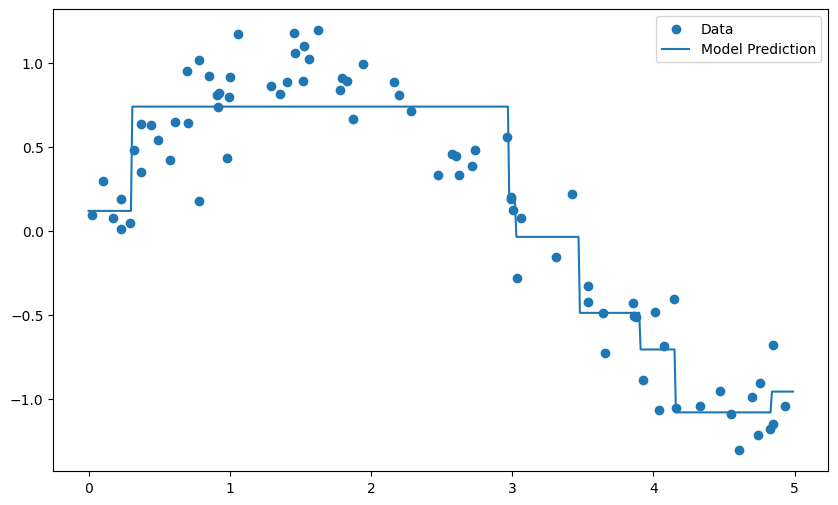

In [ ]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic dataset
rng = np.random.RandomState(42)
X = np.sort(5 * rng.rand(80, 1), axis=0)
y = np.sin(X).ravel() + rng.normal(0, 0.2, X.shape[0])

reg = DecisionTreeRegressor(max_depth=3)
reg.fit(X, y)

# Plot predictions
X_test = np.arange(0, 5, 0.01).reshape(-1, 1)
y_pred = reg.predict(X_test)

plt.figure(figsize=(10,6))
plt.scatter(X, y, label="Data")
plt.plot(X_test, y_pred, label="Model Prediction")
plt.legend()
plt.show()
